# 3 — Four wheels, one tire model, IMU-only supervision

No tire force is ever measured here. The only supervision is what an instrumented car
actually logs: $a_x$, $a_y$, yaw acceleration, wheel speeds, steering angle and
velocity. A **single shared** `TireNet` is evaluated on all four corners inside the
exact Newton–Euler equations, and the gradient of the IMU error reaches it through the
mechanics.

$$m(\dot v_x - r v_y) = \sum_i F_{x,i}^{b}, \qquad
  m(\dot v_y + r v_x) = \sum_i F_{y,i}^{b}, \qquad
  I_z \dot r = \sum_i (x_i F_{y,i}^{b} - y_i F_{x,i}^{b})$$

Nothing in those equations is learnable, so a good fit cannot hide a wrong tire behind
a learned chassis.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.3})
from tire_nn.training import set_seed
set_seed(0)

/home/poxx/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. The vehicle and its data

The generator simulates a car with a **known** Magic Formula tire and logs only vehicle
signals — the ground-truth tire is never written to the file.

In [2]:
from tire_nn.data.vehicle import make_synthetic_vehicle, VehicleDataset
from tire_nn.physics import VehicleParams

vp = VehicleParams(m=1200.0, Iz=1500.0, lf=1.3, lr=1.4, t_f=1.6, t_r=1.6, h_cg=0.45, R_e=0.32)

train_df = make_synthetic_vehicle(n_sequences=6, T=1200, dt=0.005, vp=vp,
                                  mu_values=(1.0, 0.85), tire_ids=("soft", "medium"),
                                  noise_imu=0.05, seed=0)
unseen_df = make_synthetic_vehicle(n_sequences=2, T=1200, dt=0.005, vp=vp,
                                   mu_values=(0.65,), tire_ids=("unseen",),
                                   noise_imu=0.05, seed=100)
print(f"train {len(train_df)} rows, mu in {{1.0, 0.85}}")
print(f"held-out condition: {len(unseen_df)} rows at mu = 0.65 (never trained on)")
train_df[["t", "vx", "vy", "r", "ax", "ay", "r_dot", "delta", "omega_FL"]].head(3).round(3)

train 7200 rows, mu in {1.0, 0.85}
held-out condition: 2400 rows at mu = 0.65 (never trained on)


,t,vx,vy,r,ax,ay,r_dot,delta,omega_FL
0,0.000,12.297,0.000,0.000,1.171,0.433,0.503,0.009,38.819
1,0.005,12.303,0.002,0.003,1.228,0.463,0.606,0.011,38.836
2,0.010,12.310,0.005,0.006,1.287,0.555,0.666,0.013,38.852


## 2. Corner kinematics and load transfer

Everything the tire model sees per corner comes from geometry: $v_i = v_{CoG} +
\omega \times r_i$, and quasi-static load transfer that conserves $\sum_i F_{z,i} = mg$
exactly.

sum(Fz) = 11772.0 N   m*g = 11772.0 N   max deviation 0.0020 N


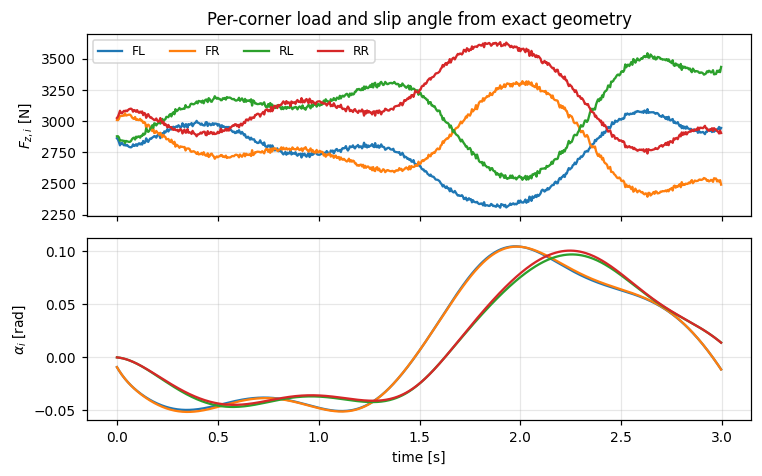

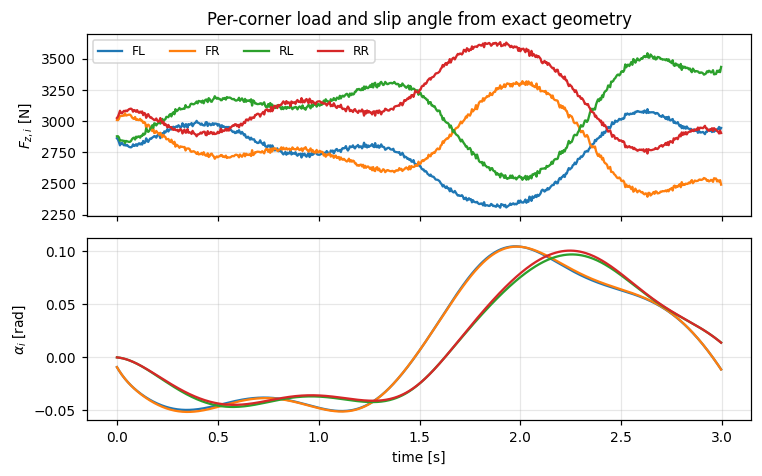

In [3]:
from tire_nn.models.four_wheel_vehicle import FourWheelVehicle
from tire_nn.models import EncodedTireNet
from tire_nn.physics import MagicFormulaTire, MFParams

probe = FourWheelVehicle(MagicFormulaTire(MFParams(mu=1.0), MFParams(mu=1.0)), vp)
seg = train_df.iloc[:600]
t = lambda c: torch.as_tensor(seg[c].to_numpy(), dtype=torch.float32)
omega = torch.stack([t(f"omega_{w}") for w in ("FL", "FR", "RL", "RR")], dim=-1)
out = probe(t("vx"), t("vy"), t("r"), t("delta"), omega, ax_meas=t("ax"), ay_meas=t("ay"))

total = out["Fz"].sum(-1)
print(f"sum(Fz) = {float(total.mean()):.1f} N   m*g = {vp.m*9.81:.1f} N   "
      f"max deviation {float((total - vp.m*9.81).abs().max()):.4f} N")

fig, axes = plt.subplots(2, 1, figsize=(7, 4.4), sharex=True)
for i, w in enumerate(("FL", "FR", "RL", "RR")):
    axes[0].plot(seg["t"], out["Fz"][:, i].detach(), label=w)
    axes[1].plot(seg["t"], out["alpha"][:, i].detach(), label=w)
axes[0].set_ylabel("$F_{z,i}$ [N]"); axes[0].legend(ncol=4, fontsize=8)
axes[1].set_ylabel(r"$\alpha_i$ [rad]"); axes[1].set_xlabel("time [s]")
axes[0].set_title("Per-corner load and slip angle from exact geometry")
fig.tight_layout(); fig

## 3. Sharing versus four independent networks

In [4]:
shared = FourWheelVehicle(EncodedTireNet(context_keys=("vx",)), vp, share_tire=True)
per_wheel = FourWheelVehicle(EncodedTireNet(context_keys=("vx",)), vp, share_tire=False)

n_s = sum(p.numel() for p in shared.parameters())
n_p = sum(p.numel() for p in per_wheel.parameters())
print(f"shared    : {n_s:5d} parameters, {len(list(shared.tire.parameters()))} tensors, one tire module")
print(f"per-wheel : {n_p:5d} parameters  ({n_p // n_s}x)")

ids = shared.shared_parameter_ids()
print(f"all four corners use the SAME parameter objects: "
      f"{ids == {id(p) for p in shared.tire.parameters()}}")

shared    :  1323 parameters, 11 tensors, one tire module
per-wheel :  5292 parameters  (4x)
all four corners use the SAME parameter objects: True


## 4. Train from IMU signals only

In [5]:
from torch.utils.data import DataLoader
from tire_nn.training.losses import vehicle_loss
from tire_nn.training.metrics import rmse

tire_index = {n: i for i, n in enumerate(sorted(set(train_df["tire_id"]) | set(unseen_df["tire_id"])))}
split = int(0.8 * train_df["sequence_id"].nunique())
seq_ids = sorted(train_df["sequence_id"].unique())
tr_ds = VehicleDataset(train_df[train_df["sequence_id"].isin(seq_ids[:split])], tire_index)
va_ds = VehicleDataset(train_df[train_df["sequence_id"].isin(seq_ids[split:])], tire_index)
un_ds = VehicleDataset(unseen_df, tire_index)

def fwd(veh, b):
    o = veh(b["vx"], b["vy"], b["r"], b["delta"], b["omega"], ax_meas=b["ax"], ay_meas=b["ay"])
    return o["ax"], o["ay"], o["r_dot"]

def train(veh, epochs=40, lr=3e-3):
    opt = torch.optim.Adam([p for p in veh.parameters() if p.requires_grad], lr=lr)
    for _ in range(epochs):
        veh.train()
        for b in DataLoader(tr_ds, batch_size=512, shuffle=True):
            opt.zero_grad(set_to_none=True)
            vehicle_loss(fwd(veh, b), (b["ax"], b["ay"], b["r_dot"])).backward()
            torch.nn.utils.clip_grad_norm_(veh.parameters(), 10.0)
            opt.step()
    return veh.eval()

@torch.no_grad()
def score(veh, ds):
    P, T = [[], [], []], [[], [], []]
    for b in DataLoader(ds, batch_size=4096):
        p, tt = fwd(veh, b), (b["ax"], b["ay"], b["r_dot"])
        for i in range(3):
            P[i].append(p[i]); T[i].append(tt[i])
    return {n: rmse(torch.cat(P[i]), torch.cat(T[i]))
            for i, n in enumerate(("ax", "ay", "r_dot"))}

from tire_nn.models import ParameterTireNet
from tire_nn.physics.fitting import fit_magic_formula
from tire_nn.data import make_synthetic

rig = make_synthetic(4000, mu=1.0, seed=7)          # rig data for ONE compound
px, py = fit_magic_formula(rig)

results = {}
for name, veh in {
    "analytical (rig fit only)": FourWheelVehicle(MagicFormulaTire(px, py), vp),
    "shared encoded":            FourWheelVehicle(EncodedTireNet(context_keys=("vx",)), vp),
    "per-wheel (ablation)":      FourWheelVehicle(EncodedTireNet(context_keys=("vx",)), vp, share_tire=False),
    "shared parameter":          FourWheelVehicle(ParameterTireNet(context_keys=("vx",)), vp),
}.items():
    if "analytical" not in name:
        train(veh)
    row = {"params": sum(p.numel() for p in veh.parameters())}
    row.update({f"val_{k}": v for k, v in score(veh, va_ds).items()})
    row.update({f"unseen_{k}": v for k, v in score(veh, un_ds).items()})
    results[name] = row
    print(f"{name:26s} done")

pd.DataFrame(results).T.round(4)

analytical (rig fit only)  done


shared encoded             done


per-wheel (ablation)       done


shared parameter           done


,params,val_ax,val_ay,val_r_dot,unseen_ax,unseen_ay,unseen_r_dot
analytical (rig fit only),0.0,0.2824,0.4858,0.1643,0.7706,1.4089,0.5097
shared encoded,1323.0,0.2878,0.2093,0.0722,0.7383,1.0049,0.7930
per-wheel (ablation),5292.0,0.1895,0.2743,0.1228,0.7192,1.3935,1.0506
shared parameter,1548.0,0.2155,0.2755,0.0930,0.7133,1.1184,0.4742


## 5. Did the tire model actually learn a tire?

The real test is not the IMU RMSE — it is whether the constitutive model that came out
is physically sane, since nothing ever showed it a tire force.

In [6]:
from tire_nn.evaluation import audit
from tire_nn.evaluation import plots

learned = FourWheelVehicle(EncodedTireNet(context_keys=("vx",)), vp)
train(learned)
report = audit(learned.tire, n=4096, context={"vx": torch.tensor([20.0])})
pd.Series(report).round(8)

sym_violation_x            0.000000e+00
sym_violation_y            0.000000e+00
zero_slip_force            0.000000e+00
zero_alpha_Fy              0.000000e+00
zero_kappa_Fx              0.000000e+00
envelope_violation         1.200000e-07
envelope_violation_frac    0.000000e+00
dissipativity_violation    0.000000e+00
dtype: float64

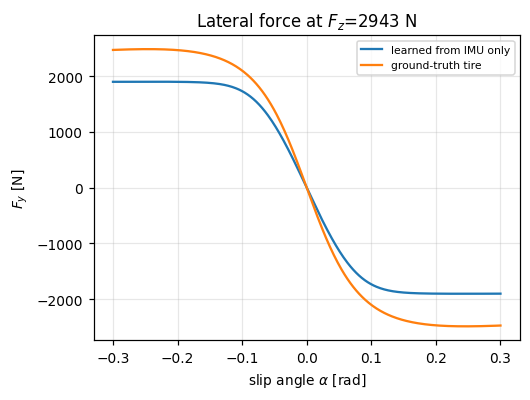

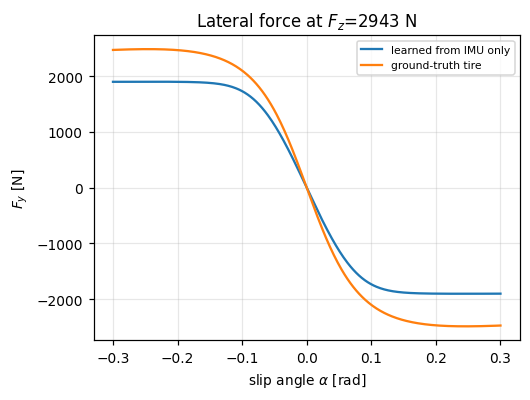

In [7]:
ref = MagicFormulaTire(MFParams(B=8.5, C=1.5, E=0.4, mu=1.0, k_mu=0.08),
                       MFParams(B=8.5, C=1.5, E=0.4, mu=1.0, k_mu=0.08))

class WithSpeed(torch.nn.Module):
    """Small shim so the plot helper can pass the vx context the tire expects."""
    def __init__(self, tire, vx=20.0):
        super().__init__(); self.tire, self.vx = tire, vx
    def forward(self, a, k, Fz, context=None):
        return self.tire(a, k, Fz, {"vx": torch.full_like(a, self.vx)})

fig = plots.plot_lateral_curve({"learned from IMU only": WithSpeed(learned.tire),
                                "ground-truth tire": ref},
                               Fz=float(vp.m * 9.81 / 4), alpha_max=0.3)
fig

The learned curve is recovered only over the slip range the car actually visited —
which is the honest limit of vehicle-level identification, and exactly why Experiment 3
supports warm-starting from rig data (`pretrain_with_tire_data: true`).

## 6. Gradient path check

The IMU error must reach the constitutive model; if it does not, the fit is coming from
somewhere else.

In [8]:
veh = FourWheelVehicle(EncodedTireNet(context_keys=("vx",)), vp)
b = next(iter(DataLoader(tr_ds, batch_size=256)))
vehicle_loss(fwd(veh, b), (b["ax"], b["ay"], b["r_dot"])).backward()

grads = {n: float(p.grad.abs().max()) for n, p in veh.tire.named_parameters() if p.grad is not None}
print(f"tire parameters receiving gradient: {len(grads)}")
print(f"largest gradient magnitude        : {max(grads.values()):.4g}")
print(f"learnable chassis parameters      : "
      f"{sum(1 for p in veh.parameters() if id(p) not in {id(q) for q in veh.tire.parameters()})}")

tire parameters receiving gradient: 10
largest gradient magnitude        : 0.05012
learnable chassis parameters      : 0


## Takeaways

1. A tire model **can** be identified from IMU-level signals alone, because the exact
   Newton–Euler equations carry the gradient from acceleration error to the
   constitutive law.
2. Sharing one tire across four corners uses a quarter of the parameters of the
   per-wheel ablation. On the held-out friction level it is clearly better on the
   lateral and yaw channels and comparable on the longitudinal one — each vehicle
   sample becomes four constraints on one law instead of one constraint on four.
3. Zero learnable chassis parameters means a fit cannot be bought with a wrong $I_z$.
4. The identified curve is only trustworthy over the slip range the car visited. Warm
   start from rig data when you have it.